<a href="https://colab.research.google.com/github/TaisRol/AprendizajeAutomatico1/blob/main/TP4_AA2_Roldan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CarRacing-v3 con DQN
##Por Tais Roldan

###En este trabajo voy a seguir el tutorial [Control CartRacing-v2 environment using DQN from scratch](https://hiddenbeginner.github.io/study-notes/contents/tutorials/2023-04-20_CartRacing-v2_DQN.html)

En este tutorial vamos a implementar el algoritmo DNQ (Deep Q-Network o Aprendizaje por refuerzo profundo) para controlar el entorno CartRacing-v3 (el tutorial tiene la versión 2), el cual tiene un espacio de observación basado en imágenes.
Vamos a enfocarnos más en como convertir un entorno original (sin procesar) en un entorno MDP.

---
##Entorno de CarRacing-v3
Primero vamos a observar el entorno de CArRAcing-v3. Ya que DQN puede aplicarse a entornos con espacios de accion discreta, tenemos que pasar continuous=False.


Descipción: La tarea de control más sencilla para aprender a partir de píxeles: un entorno de carreras con vista cenital. La pista generada es aleatoria en cada episodio.

Algunos indicadores se muestran en la parte inferior de la ventana junto con el búfer RGB de estado. De izquierda a derecha: velocidad real, cuatro sensores ABS, posición del volante y giroscopio. Para jugar (es bastante rápido para los humanos), escribe:

```
python gymnasium/envs/box2d/car_racing.py
```

Recuerda: es un coche potente de tracción trasera; no pises el acelerador y gires al mismo tiempo.

###Espacio de acción
Si es continuo, hay 3 acciones:

0: dirección, -1 es completamente a la izquierda, +1 es completamente a la derecha.

1: gas

2: frenado

Si es discreto, hay 5 acciones:

0: no hacer nada

1: gira a la derecha

2: girar a la izquierda

3: gas

4: freno

###Espacio de observación
Imagen RGB de 96x96 píxeles tomada desde arriba del coche y la pista de carreras.

###Recompensas
La recompensa es de -0,1 por cada fotograma y +1000/N por cada casilla del recorrido visitada, donde N es el número total de casillas visitadas en el recorrido. Por ejemplo, si terminas en 732 fotogramas, tu recompensa es 1000 - 0,1 * 732 = 926,8 puntos.

###Estado inicial
El coche arranca desde parado en el centro de la carretera.

###Finalización del episodio
El episodio termina cuando se visitan todas las casillas. El coche también puede salirse del área de juego, es decir, alejarse de la pista, en cuyo caso recibirá una recompensa de -100 y será destruido.

---

##Empezamos con el tutorial
Para empezar vamos a importar las librerias necesarias

Las instalaciones no se especifican en el tutorial pero son necesarias.

In [1]:
!pip install swig
!pip install "gymnasium[box2d]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 48.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

Observamos el Entorno

Para empezar primero tenemos que cambiar la version de Car Racing, ya que si bien el tutorial es de la v2, actualmente se usa la v3

In [3]:
env = gym.make('CarRacing-v3', continuous=False) #Aca reemplacé v2 por v3
print("Observation space: ", env.observation_space)
print("Action space: ", env.action_space)

Observation space:  Box(0, 255, (96, 96, 3), uint8)
Action space:  Discrete(5)


Ahora vamos a ver el estado inicial.

(96, 96, 3)


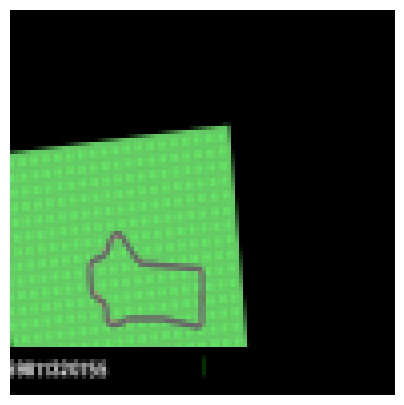

In [4]:
s, info = env.reset()
print(s.shape)

plt.figure(figsize=(5, 5))
plt.imshow(s)
plt.axis('off')
plt.show()

¿Que estamos viendo acá? En esta imagen podemos observar el primer cuadro o el primer paso de cuando inicia el juego.
Si observamos los primeros 50 pasos del juego, vamos a poder darnos cuenta que la imagen se va acercando al "circuito" y al auto.

También tenemos que tomar en cuenta que solo se nos proporciona un fotograma del juego actual para cada paso. Esta configuración no puede satisfacer **la propiedad de Markov**, esto significa que el estado actual (el frame) no tiene toda la inofrmación necesaria para decidir o predecir lo que va a suceder a continuación, ya que el agente al ver el cuadro, solo sabrá donde está el auto, no si está avanzando o no, si esta derrapando hacia atrás o a que velocidad va.

Por lo tanto, necesitamos apilar los fotogramas anteriores. k=4 marcos.

El artículo de DQN dice:
* Los fotogramas sin procesar se preprocesan convirtiendo primero su representación RGB a escala de grises
* La representación de entrada final se obtiene recortando una región de 84 × 84 de la imagen que captura aproximadamente el área de juego.
* Para los experimentos de este artículo, la función
El algoritmo 1 aplica este preprocesamiento a los últimos 4 fotogramas de un historial y los apila para producir la entrada a la función Q.
* También utilizamos una técnica simple de salto de fotogramas [3]. Más precisamente, el agente ve y selecciona acciones en cada fotograma k en lugar de en cada fotograma, y ​​su última acción se repite en los fotogramas omitidos.



A partir de ahora, convertiremos CarRacing-v3 el entorno al formato anterior. Primero definamos una función para preprocesar cada fotograma del juego.

Podemos usar cualquier método para redimensionar los fotogramas a 84 x 84. La forma más sencilla es reescalarlos. Pero aquí aprovecharemos nuestro conocimiento del juego. Cada fotograma siempre tiene un área negra en la parte inferior, así que lo mejor es recortarla.

In [5]:
import cv2

def preprocess(img):
    img = img[:84, 6:90] # CarRacing-v2-specific cropping
    # img = cv2.resize(img, dsize=(84, 84)) # or you can simply use rescaling

    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) / 255.0
    return img

Ahora, cambiaremos la configuración inicial (reset método a continuación) y las observaciones ( step método a continuación).

In [6]:
class ImageEnv(gym.Wrapper):
    def __init__(
        self,
        env,
        skip_frames=4,
        stack_frames=4,
        initial_no_op=50,
        **kwargs
    ):
        # Inicializa la clase padre (gym.Wrapper) con el entorno original
        super(ImageEnv, self).__init__(env, **kwargs)

        # initial_no_op: Cantidad de pasos al inicio del episodio donde el agente no hace nada.
        # En CarRacing, el juego empieza con una animación donde la cámara hace "zoom" hacia el auto.
        # Es mejor dejar pasar esos fotogramas para no confundir a la red neuronal.
        self.initial_no_op = initial_no_op

        # skip_frames: Cuántos fotogramas saltar. En lugar de tomar una decisión 60 veces por segundo,
        # el agente elige una acción y la mantiene apretada durante 4 fotogramas. Esto acelera el entrenamiento.
        self.skip_frames = skip_frames

        # stack_frames: Cuántas imágenes juntas forman un "Estado" (para entender la velocidad y dirección).
        self.stack_frames = stack_frames

    def reset(self):
        # Reinicia el entorno original para empezar una nueva carrera.
        s, info = self.env.reset()

        # Bucle de calentamiento: el auto se queda quieto (acción 0) durante los primeros 50 pasos
        # para dejar que termine la animación inicial del juego.
        for i in range(self.initial_no_op):
            s, r, terminated, truncated, info = self.env.step(0)

        # Pasa el fotograma por una función (que seguro tienes definida en otro lado)
        # para achicar la imagen a 84x84 y pasarla a blanco y negro (escala de grises).
        s = preprocess(s)

        # Como acaba de empezar la carrera y no tenemos imágenes del pasado,
        # simplemente copiamos esta primera imagen 4 veces para crear nuestro "estado apilado" inicial.
        self.stacked_state = np.tile(s, (self.stack_frames, 1, 1))  # Resultado: Tensor de [4, 84, 84]

        return self.stacked_state, info

    def step(self, action):
        # Ejecuta la acción elegida, pero la mantiene durante 'skip_frames' (ej. 4 pasos seguidos)
        reward = 0
        for _ in range(self.skip_frames):
            s, r, terminated, truncated, info = self.env.step(action)
            reward += r # Va sumando las recompensas obtenidas en esos micro-pasos

            # Si el auto choca o termina la pista en medio del salto, cortamos el bucle.
            if terminated or truncated:
                break

        # Preprocesa la nueva imagen que quedó después del salto (achicar y blanco/negro)
        s = preprocess(s)

        # Actualiza el historial de imágenes (el "stack"):
        # Toma las últimas 3 imágenes (self.stacked_state[1:] descarta la más vieja en la posición 0)
        # y le concatena la imagen nueva al final. Así siempre mantenemos exactamente 4 fotogramas.
        self.stacked_state = np.concatenate((self.stacked_state[1:], s[np.newaxis]), axis=0)

        # Devuelve el nuevo paquete de 4 imágenes, la recompensa total del salto, y si el juego terminó.
        return self.stacked_state, reward, terminated, truncated, info

Podemos crear el entorno deseado de la siguiente manera:

The shape of an observation:  (4, 84, 84)


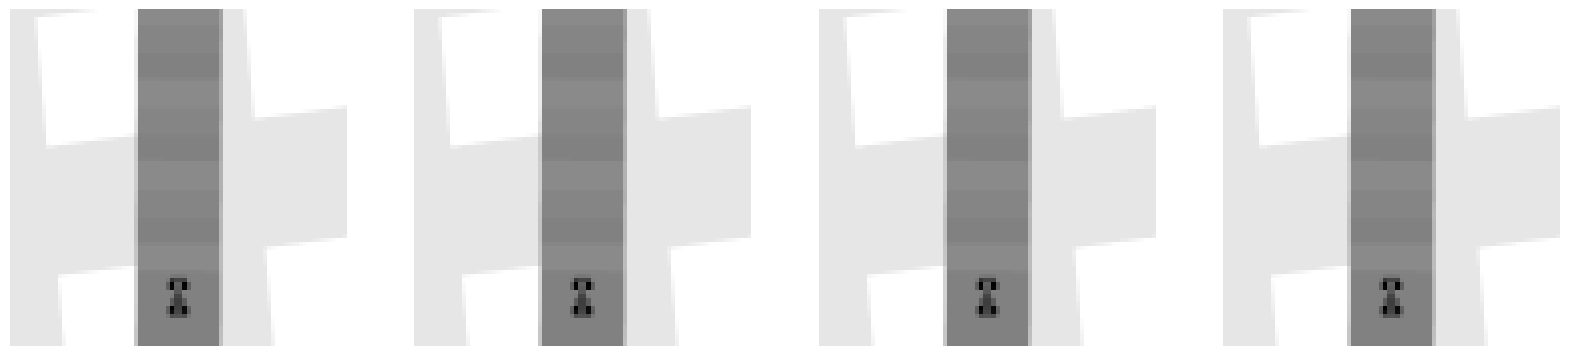

In [7]:
env = gym.make('CarRacing-v3', continuous=False)
env = ImageEnv(env)

s, _ = env.reset()
print("The shape of an observation: ", s.shape)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i in range(4):
    axes[i].imshow(s[i], cmap='gray')
    axes[i].axis('off')
plt.show()

Pasemos la acción "gas" (acelerar) a los siguientes 4 pasos, ahora nuestro auto se va a mover para adelante! (se puede notar por el fondo)

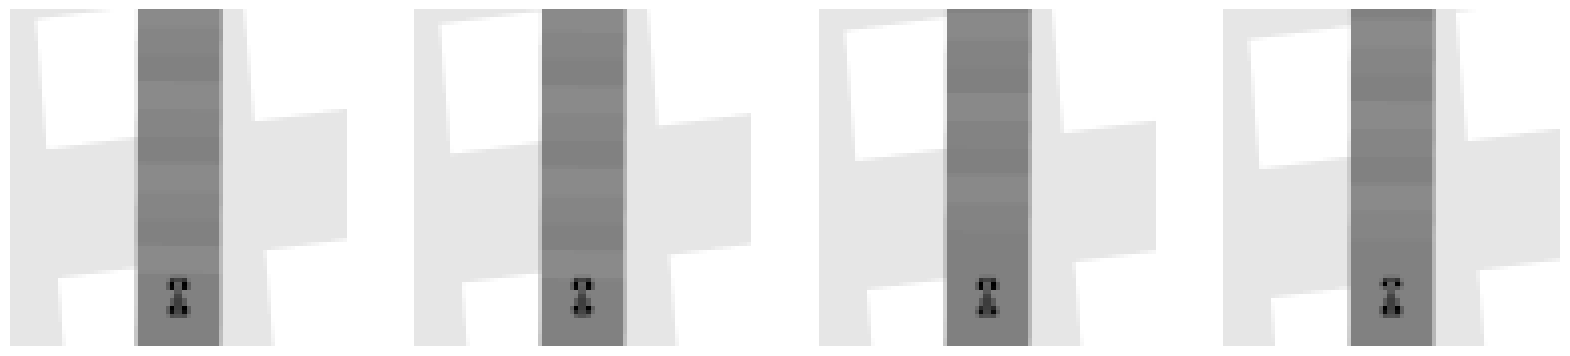

In [8]:
for i in range(4):
    s, r, terminated, truncated, info = env.step(3)  #La acción n3 es la de "gas" (acelerar)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i in range(4):
    axes[i].imshow(s[i], cmap='gray')
    axes[i].axis('off')
plt.show()

---
##Red Q

El artículo de DQN dice que la entrada a la red neuronal consiste en una imagen de 84 × 84 × 4 producida por Ø La primera capa oculta convoluciona 16 filtros de 8 × 8 con paso 4 con la imagen de entrada y aplica una no linealidad rectificadora [10, 18]. La segunda capa oculta convoluciona 32 filtros de 4 × 4 con paso 2, seguidos nuevamente de una no linealidad rectificadora. La capa oculta final es totalmente conectada y consta de 256 unidades rectificadoras. La capa de salida es una capa lineal totalmente conectada con una única salida para cada acción válida.

In [9]:
import torch.nn as nn
import torch.nn.functional as F

class CNNActionValue(nn.Module):
    # Inicializa las capas que conformarán la red neuronal
    def __init__(self, state_dim, action_dim, activation=F.relu):
        super(CNNActionValue, self).__init__()

        # PRIMERA CAPA CONVOLUCIONAL (Los "ojos" de nivel bajo):
        # Toma las imágenes de entrada (ej. 4 frames apilados de 84x84).
        # Usa un "filtro" (kernel) de 8x8 que salta de 4 en 4 píxeles (stride=4).
        # Convierte las 4 imágenes en 16 "mapas de características" de 20x20.
        self.conv1 = nn.Conv2d(state_dim, 16, kernel_size=8, stride=4)

        # SEGUNDA CAPA CONVOLUCIONAL (Los "ojos" de nivel alto):
        # Toma los 16 mapas anteriores y usa un filtro de 4x4 saltando de 2 en 2.
        # Esto reduce la imagen a 32 mapas más abstractos de 9x9.
        self.conv2 = nn.Conv2d(16, 32, kernel_size=4, stride=2)

        # APLANAMIENTO (Flatten):
        # Para pasar la información a una red neuronal tradicional, debemos "desenrollar"
        # esos 32 mapas de 9x9 en una sola fila larga de números.
        # 32 * 9 * 9 = 2592 características.
        self.in_features = 32 * 9 * 9

        # PRIMERA CAPA LINEAL (El "cerebro" pensante):
        # Toma las 2592 características visuales y las conecta a 256 "neuronas".
        self.fc1 = nn.Linear(self.in_features, 256)

        # CAPA DE SALIDA (Las "manos" del agente):
        # Toma las 256 neuronas y las reduce a la cantidad exacta de acciones posibles (action_dim).
        # Cada salida representará el "Valor Q" (qué tan buena es esa acción).
        self.fc2 = nn.Linear(256, action_dim)

        # Función de activación (ReLU): "Apaga" los valores negativos para permitir aprendizaje complejo.
        self.activation = activation

    # Define CÓMO viaja la información desde que entra la imagen hasta que sale la acción
    def forward(self, x):
        # Pasa por la capa convolucional 1 y aplica ReLU (elimina negativos)
        x = F.relu(self.conv1(x))

        # Pasa por la capa convolucional 2 y aplica ReLU
        x = F.relu(self.conv2(x))

        # "Aplana" la matriz 3D en un vector 1D usando la dimensión que calculamos antes
        # El -1 le dice a PyTorch que mantenga automáticamente el tamaño del batch (lote)
        x = x.view((-1, self.in_features))

        # Pasa por la primera capa lineal (neuronas ocultas)
        x = self.fc1(x)

        # Pasa por la capa final, que nos da los puntajes (Q-values) para cada acción
        x = self.fc2(x)

        return x

##Búfer de reproducción
Para la implementación del búfer de reproducción, la creación previa de los arreglos necesarios es más eficiente que el uso de collections.queue. Para esto, el tutorial usa [la implementación oficial de TD3.](https://github.com/sfujim/TD3/blob/master/utils.py#L5)

In [10]:
class ReplayBuffer:
    # Inicializa la memoria (Replay Buffer) definiendo sus dimensiones y capacidad máxima.
    def __init__(self, state_dim, action_dim, max_size=int(1e5)):
        # Pre-asignamos memoria creando matrices de NumPy llenas de ceros.
        # Hacer esto desde el principio es mucho más eficiente que crear listas dinámicas
        # e ir agregándoles elementos uno por uno (especialmente con imágenes pesadas).
        self.s = np.zeros((max_size, *state_dim), dtype=np.float32)         # Almacena los estados actuales (las imágenes del entorno)
        self.a = np.zeros((max_size, *action_dim), dtype=np.int64)          # Almacena las acciones que tomó el agente
        self.r = np.zeros((max_size, 1), dtype=np.float32)                  # Almacena las recompensas obtenidas tras la acción
        self.s_prime = np.zeros((max_size, *state_dim), dtype=np.float32)   # Almacena los siguientes estados (las imágenes después de la acción)
        self.terminated = np.zeros((max_size, 1), dtype=np.float32)         # Almacena si el episodio terminó ahí (1 = Sí, 0 = No)

        self.ptr = 0             # Puntero: indica el índice donde se guardará la PRÓXIMA experiencia
        self.size = 0            # Tamaño actual: indica cuántas experiencias tenemos guardadas en este momento
        self.max_size = max_size # Capacidad máxima de nuestro buffer (ej. 10,000 en tu demo)

    # El método update guarda una nueva transición (experiencia) en la memoria
    def update(self, s, a, r, s_prime, terminated):
        # Sobrescribe la fila indicada por el puntero (self.ptr) con los nuevos datos
        self.s[self.ptr] = s
        self.a[self.ptr] = a
        self.r[self.ptr] = r
        self.s_prime[self.ptr] = s_prime
        self.terminated[self.ptr] = terminated

        # Actualiza el puntero. El uso de módulo (%) crea un "búfer circular".
        # Si el puntero llega al límite (max_size), vuelve a 0 y empieza a sobrescribir
        # las experiencias más viejas, evitando así que el programa se quede sin RAM.
        self.ptr = (self.ptr + 1) % self.max_size

        # Aumenta el tamaño de experiencias disponibles, con un tope en 'max_size'
        self.size = min(self.size + 1, self.max_size)

    # El método sample extrae un "lote" aleatorio de experiencias para entrenar a la red neuronal
    def sample(self, batch_size):
        # Genera índices aleatorios entre 0 y la cantidad de datos que tenemos guardados
        ind = np.random.randint(0, self.size, batch_size)

        # Devuelve las experiencias ubicadas en esos índices aleatorios.
        # Convierte los arrays de NumPy directamente a Tensores de PyTorch (FloatTensor)
        # porque la red neuronal solo "entiende" tensores.
        return (
            torch.FloatTensor(self.s[ind]),
            torch.FloatTensor(self.a[ind]),
            torch.FloatTensor(self.r[ind]),
            torch.FloatTensor(self.s_prime[ind]),
            torch.FloatTensor(self.terminated[ind]),
        )

##DQN
El agente DQN tiene 4 metodos
* __init__() como siempre
* act() toma como entrada un estado de tipo np.ndarray y genera acciones siguiendo una política epsilon-greedy.
* process() toma una transición como entrada y define lo que hace el agente en cada paso.
* learn() toma una muestra de un mini-lote del búfer de repetición y entrena la Red Q

En el artículo original (paper) de DQN, utilizaron un búfer de repetición con un tamaño de 1.000.000, lo cual requiere una enorme cantidad de memoria que no se puede cargar en mi pequeña memoria RAM. Para la política epsilon-greedy, usaron un valor de epsilon inicial de 1.0 y lo disminuyeron de forma lineal hasta 0.1 durante el primer millón de pasos, manteniéndolo fijo en 0.1 a partir de entonces.

In [11]:
import torch
import torch.nn.functional as F
import numpy as np

class DQN:
    def __init__(
        self,
        state_dim,
        action_dim,
        lr=0.00025,
        epsilon=1.0,
        epsilon_min=0.1,
        gamma=0.99,
        batch_size=32,
        # CAMBIO 1: Reducimos los pasos de calentamiento (antes 5000)
        warmup_steps=1000,
        # CAMBIO 2: Reducimos drásticamente el tamaño del buffer para salvar la RAM (antes 100.000)
        buffer_size=10000,
        # CAMBIO 3: Actualizamos la red objetivo más seguido en la demo (antes 10.000)
        target_update_interval=1000,
    ):
        self.action_dim = action_dim
        self.epsilon = epsilon
        self.gamma = gamma
        self.batch_size = batch_size
        self.warmup_steps = warmup_steps
        self.target_update_interval = target_update_interval

        # Inicializamos las dos redes neuronales (Principal y Objetivo)
        self.network = CNNActionValue(state_dim[0], action_dim)
        self.target_network = CNNActionValue(state_dim[0], action_dim)

        # Igualamos los pesos iniciales de ambas redes
        self.target_network.load_state_dict(self.network.state_dict())
        self.optimizer = torch.optim.RMSprop(self.network.parameters(), lr)

        # Inicializamos la memoria donde el agente guardará sus experiencias pasadas
        self.buffer = ReplayBuffer(state_dim, (1, ), buffer_size)

        # Detectamos si hay tarjeta gráfica (GPU) disponible, si no, usamos el procesador (CPU)
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.network.to(self.device)
        self.target_network.to(self.device)

        self.total_steps = 0

        # CAMBIO 4: Hacemos que epsilon decaiga mucho más rápido (en 10.000 pasos en lugar de 1.000.000).
        # Así el agente dejará de tomar acciones aleatorias más temprano.
        self.epsilon_decay = (epsilon - epsilon_min) / 10000

    @torch.no_grad() # Desactiva el cálculo de gradientes para ahorrar memoria/tiempo durante la inferencia
    def act(self, x, training=True):
        self.network.train(training)

        # Política Epsilon-Greedy: Decide si explorar (acciones aleatorias) o explotar (usar la red)
        # Si estamos calentando o el número aleatorio es menor a epsilon, exploramos.
        if training and ((np.random.rand() < self.epsilon) or (self.total_steps < self.warmup_steps)):
            a = np.random.randint(0, self.action_dim) # Toma una acción al azar
        else:
            # Convierte la imagen (numpy array) a un tensor de PyTorch y la pasa a la GPU/CPU
            x = torch.from_numpy(x).float().unsqueeze(0).to(self.device)
            q = self.network(x) # Pasa la imagen por la red neuronal
            a = torch.argmax(q).item() # Elige la acción con el valor Q más alto (la mejor acción estimada)
        return a

    def learn(self):
        # Toma una muestra aleatoria (mini-batch) de experiencias pasadas desde el Replay Buffer
        s, a, r, s_prime, terminated = map(lambda x: x.to(self.device), self.buffer.sample(self.batch_size))

        # Calcula el valor Q del siguiente estado usando la Red Objetivo (Target Network)
        next_q = self.target_network(s_prime).detach()

        # Ecuación de Bellman: Calcula cuál "debería" ser el valor correcto (target)
        td_target = r + (1. - terminated) * self.gamma * next_q.max(dim=1, keepdim=True).values

        # Calcula el error (MSE) entre lo que predijo la red principal y el valor correcto (target)
        loss = F.mse_loss(self.network(s).gather(1, a.long()), td_target)

        # Backpropagation: Ajusta los pesos de la red para aprender de este error
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        result = {
            'total_steps': self.total_steps,
            'value_loss': loss.item()
        }
        return result

    def process(self, transition):
        result = {}
        self.total_steps += 1

        # Guarda la experiencia actual (estado, acción, recompensa, siguiente estado) en la memoria
        self.buffer.update(*transition)

        # Solo empezamos a entrenar (aprender) si ya pasamos la fase de calentamiento
        if self.total_steps > self.warmup_steps:
            result = self.learn()

        # Cada cierto tiempo, copiamos los pesos aprendidos de la Red Principal a la Red Objetivo
        if self.total_steps % self.target_update_interval == 0:
            self.target_network.load_state_dict(self.network.state_dict())

        # Reducimos un poco el valor de epsilon para que el agente explore menos a medida que aprende
        if self.epsilon > 0.1: # Aseguramos que no baje del mínimo (0.1)
            self.epsilon -= self.epsilon_decay

        return result

##Entrenamiento del agente DQN
Entrenaremos al agente DQN hasta que el número total de interacciones con el entorno alcance los 20mil pasos (en vez de 2 millones como el tutorial)y evaluaremos a nuestro agente cada 2.000 pasos (en vez de 10mil).

In [12]:
env = gym.make('CarRacing-v3', continuous=False)
env = ImageEnv(env)

max_steps = int(2e4) #cambio a 20mil pasos en vez de 2millones (2e6)
eval_interval = 2000 #hago que evalue cada 2,000 pasos (en vez de 10mil)
state_dim = (4, 84, 84)
action_dim = env.action_space.n

agent = DQN(state_dim, action_dim)

In [13]:
# Definimos la función de evaluación. Al poner n_evals=1, solo jugará 1 partida de prueba.
def evaluate(n_evals=1):
    # Crea un entorno de carreras completamente nuevo e independiente
    # para no interferir con el entorno principal donde está entrenando.
    eval_env = gym.make('CarRacing-v3', continuous=False)
    eval_env = ImageEnv(eval_env)

    scores = 0 # Aquí acumularemos el puntaje total obtenido

    # Repite la prueba la cantidad de veces indicada (en este caso, solo 1 vez)
    for i in range(n_evals):
        # Resetea el entorno: obtiene el estado inicial (s), marca que no ha terminado (done=False)
        # y pone la recompensa acumulada del episodio (ret) en 0.
        (s, _), done, ret = eval_env.reset(), False, 0

        # Bucle principal de la partida: se ejecuta mientras el auto siga en la pista
        while not done:
            # Pide a la red neuronal que elija una acción.
            # IMPORTANTE: training=False apaga la exploración (epsilon) y obliga al
            # agente a usar solo su conocimiento aprendido (explotación pura).
            a = agent.act(s, training=False)

            # Ejecuta la acción en el entorno y observa las consecuencias
            s_prime, r, terminated, truncated, info = eval_env.step(a)

            # Actualiza el estado actual para el siguiente ciclo
            s = s_prime

            # Suma la recompensa obtenida en este paso al total de la partida
            ret += r

            # Verifica si el episodio terminó (el auto chocó, se salió o se acabó el tiempo)
            done = terminated or truncated

        # Al terminar la partida, suma el puntaje de esta ronda al puntaje general
        scores += ret

    # Devuelve el puntaje promedio de todas las partidas jugadas, redondeado a 4 decimales.
    # (Como n_evals=1, devolverá simplemente el puntaje de esa única partida).
    return np.round(scores / n_evals, 4)

In [16]:
from IPython.display import clear_output # Se usa en Jupyter/Colab para borrar la salida anterior de la celda
import matplotlib.pyplot as plt # (Asumo que ya lo tienes importado) Para dibujar la gráfica

# Diccionario para guardar el historial del rendimiento del agente.
# Guardaremos en qué paso estamos y cuál fue el puntaje promedio en ese momento.
history = {'Step': [], 'AvgReturn': []}

# Inicia el entorno y obtiene la primera imagen (estado inicial)
(s, _) = env.reset()

# Comienza el bucle principal de entrenamiento
while True:
    # 1. EL AGENTE ACTÚA: Observa el estado 's' y decide qué acción tomar 'a'
    a = agent.act(s)

    # 2. EL ENTORNO RESPONDE: Se ejecuta la acción en la pista de carreras.
    # El entorno nos devuelve la nueva imagen (s_prime), la recompensa (r),
    # y si el episodio terminó (terminated/truncated).
    s_prime, r, terminated, truncated, info = env.step(a)

    # 3. EL AGENTE PROCESA Y APRENDE: Guarda esta experiencia en su memoria (ReplayBuffer).
    # Si ya pasó la fase de calentamiento, aquí también entrenará su red neuronal (aprenderá).
    result = agent.process((s, a, r, s_prime, terminated))

    # 4. AVANCE DEL TIEMPO: El "nuevo estado" se convierte en el "estado actual" para el siguiente ciclo.
    s = s_prime

    # Si el auto chocó, se salió de la pista o se acabó el tiempo máximo del episodio...
    if terminated or truncated:
        s, _ = env.reset() # ...volvemos a poner el auto en la línea de salida.

    # 5. EVALUACIÓN Y GRÁFICOS: Cada vez que alcanzamos el "eval_interval" (ej. cada 2000 pasos)
    if agent.total_steps % eval_interval == 0:
        ret = evaluate() # Toma el examen: juega 1 partida sin explorar para ver cuánto aprendió.

        # Guarda los resultados en el historial
        history['Step'].append(agent.total_steps)
        history['AvgReturn'].append(ret)

        # Borra la gráfica anterior para que no se amontonen las imágenes
        clear_output()

        # Dibuja la nueva gráfica de progreso
        plt.figure(figsize=(8, 5))
        plt.plot(history['Step'], history['AvgReturn'], 'r-') # Dibuja una línea roja
        plt.xlabel('Paso (Step)', fontsize=16)
        plt.ylabel('Puntaje Promedio (AvgReturn)', fontsize=16)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.grid(axis='y') # Pone líneas horizontales para leer mejor el puntaje
        plt.show()

        # 6. GUARDAR PROGRESO: Guarda los "pesos" (el conocimiento aprendido) de la red neuronal en un archivo.
        # Si el programa se corta, puedes cargar este archivo 'dqn.pt' para no empezar desde cero.
        torch.save(agent.network.state_dict(), 'dqn.pt')

    # 7. CONDICIÓN DE PARADA: Si ya llegamos al límite máximo de pasos de nuestra demo (ej. 20,000)...
    if agent.total_steps > max_steps:
        break # ...rompe el bucle infinito y termina el programa.

KeyboardInterrupt: 

Así se deberia de ver el gráfico:


 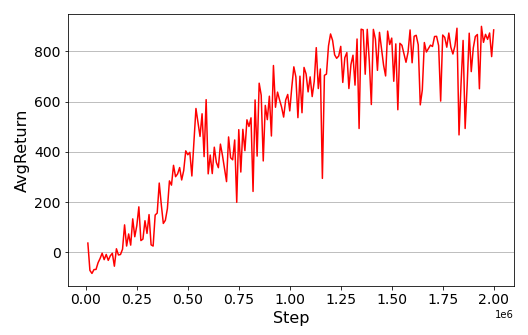

##Evaluación
Al terminar la evaluación tendriamos que poder observar como el agente aprendió a conducir nuestro auto, a seguir el juego.

In [ ]:
eval_env = gym.make('CarRacing-v3', continuous=False, render_mode='rgb_array')
eval_env = ImageEnv(eval_env)

frames = []
scores = 0
(s, _), done, ret = eval_env.reset(), False, 0
while not done:
    frames.append(eval_env.render())
    a = agent.act(s, training=False)
    s_prime, r, terminated, truncated, info = eval_env.step(a)
    s = s_prime
    ret += r
    done = terminated or truncated
scores += ret

In [ ]:
def animate(imgs, video_name, _return=True):
    import cv2
    import os
    import string
    import random

    if video_name is None:
        video_name = ''.join(random.choice(string.ascii_letters) for i in range(18)) + '.webm'
    height, width, layers = imgs[0].shape
    fourcc = cv2.VideoWriter_fourcc(*'VP90')
    video = cv2.VideoWriter(video_name, fourcc, 10, (width, height))

    for img in imgs:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        video.write(img)
    video.release()
    if _return:
        from IPython.display import Video
        return Video(video_name)

In [ ]:
animate(frames, None)

Algo así se veria el output (pero animado)
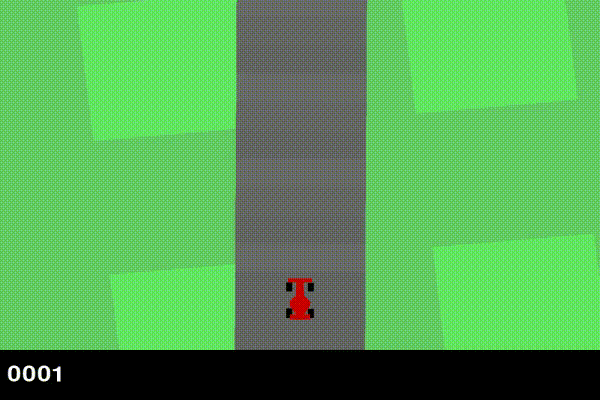

Fuentes:

Tutorial: [Control CartRacing-v2 environment using DQN from scratch](https://hiddenbeginner.github.io/study-notes/contents/tutorials/2023-04-20_CartRacing-v2_DQN.html)

Gemini para traducir algunos bloques de texto y para explicar bien como funcionaban partes del código:https://share.gemini.google/sQETvRGBsA68